# Loan Approvals

In [5]:
!pip cache purge --quiet

In [6]:
!pip install lime==0.2.0.1 \
             matplotlib==3.10.5 \
             scikit-learn==1.7.1 \
             seaborn==0.13.2 \
             shap==0.48.0 --quiet

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

INFO:matplotlib.font_manager:generated new fontManager


In [8]:
# If you've forked this repo, change OWNER to your GitHub username.
# REPO and BRANCH will normally stay the same unless you renamed them.
OWNER = "singlestore-cookbook"
REPO = "singlestore-cookbook.github.io"
BRANCH = "refs/heads/main"

BASE_URL = f"https://raw.githubusercontent.com/{OWNER}/{REPO}/{BRANCH}/code/part-ml/building-predictive-analytics-for-loan-approvals/datasets"

In [9]:
loans_csv_url = f"{BASE_URL}/loans.csv"

loans_df = pd.read_csv(loans_csv_url)

In [10]:
loans_df.head()

,ID,IssueDate,AnnualIncome,MonthlyIncome,LoanAmount,Term,InterestRate,EmploymentLength,HomeOwnership,LoanPurpose,DebtToIncome,OpenCreditLines,RevolUtilization,HighIncome_LowDTI,InterestImpact,LoanStatus
0,849,2015-01-01 18:06:37,43624,3635.33,8257.920192,60,19.42,13,rent,other,29.13,10,79.73,0,3.676076,0
1,378,2015-01-03 16:53:17,97575,8131.25,14820.090985,60,12.51,20,mortgage,major_purchase,3.76,8,99.80,1,1.900051,0
2,889,2015-01-06 21:33:10,66271,5522.58,12601.890791,60,16.99,11,rent,car,3.32,17,68.52,0,3.230718,1
3,141,2015-01-17 08:36:27,95450,7954.17,1387.446055,60,8.04,8,own,vacation,16.53,1,22.31,1,0.116867,1
4,915,2015-01-18 13:17:40,43275,3606.25,1688.485297,60,28.58,4,rent,car,0.00,3,11.24,0,1.115096,0


In [11]:
# Count how many times each class appears
loans_df["LoanStatus"].map({0: "Denied", 1: "Approved"}).value_counts()

LoanStatus
Approved    634
Denied      366
Name: count, dtype: int64

In [12]:
# Separate features and target variable
X = loans_df.drop(columns = ["ID", "LoanStatus", "IssueDate"])
y = loans_df["LoanStatus"].astype(int)

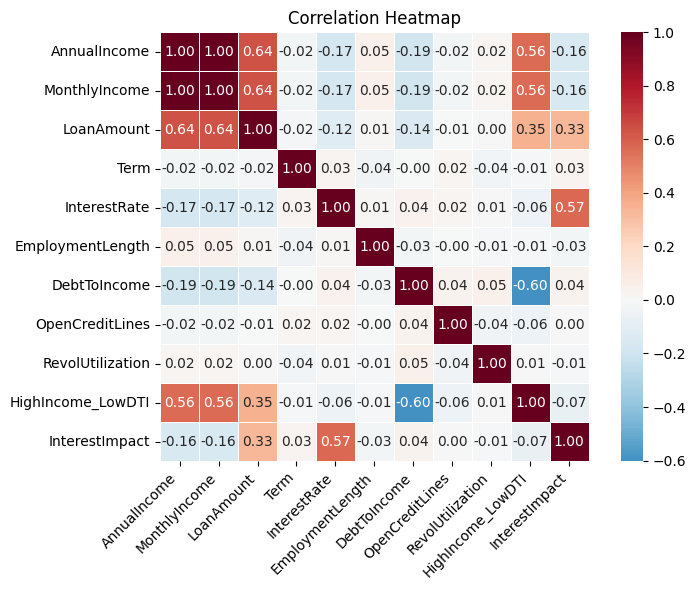

In [13]:
# Compute correlation matrix for numeric columns
corr_matrix = X.corr(numeric_only = True)

# Set up the matplotlib figure
plt.figure(figsize = (8, 6))

# Create a heatmap with annotations and diverging colormap
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "RdBu_r",
    center = 0,
    square = True,
    cbar = True,
    linewidths = 0.5
)

# Rotate x-axis labels for readability
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

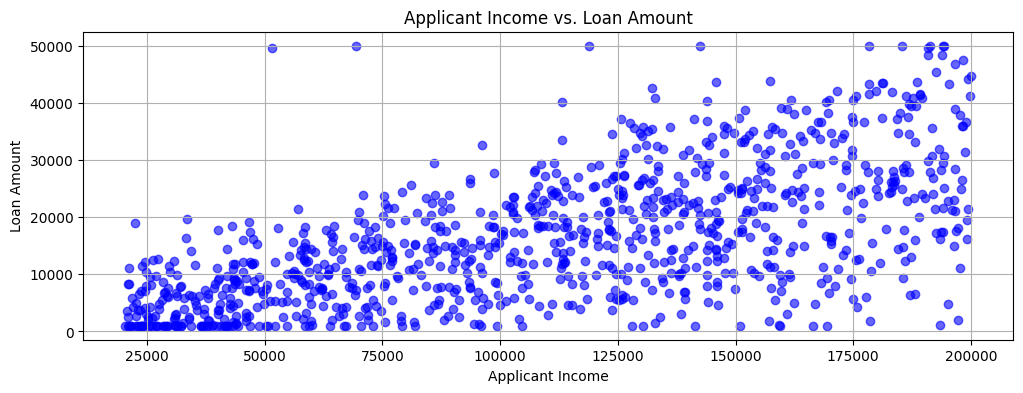

In [14]:
# Create the scatter plot
plt.figure(figsize = (12, 4))
plt.title("Applicant Income vs. Loan Amount")

plt.grid(True)
plt.scatter(loans_df["AnnualIncome"], loans_df["LoanAmount"], c = "b", alpha = 0.6)
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.show()

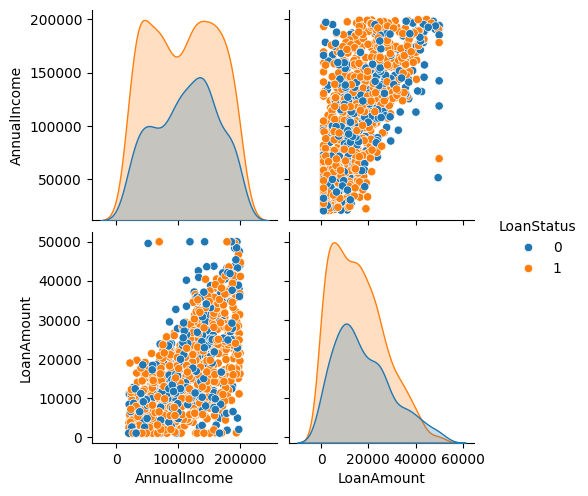

In [15]:
# Select the numerical features for plotting
numerical_features = ["AnnualIncome", "LoanAmount"]

# Combine with target
data_to_plot = pd.concat([loans_df[numerical_features], loans_df["LoanStatus"]], axis = 1)

# Create the pair plot
sns.pairplot(data_to_plot, hue = "LoanStatus", diag_kind = "kde")

In [16]:
# Identify categorical columns
categorical_cols = ["HomeOwnership", "LoanPurpose", "Term"]

# Make a copy of the dataset to avoid modifying the original
X_cat = loans_df.copy()

# Apply one-hot encoding to all categorical variables
X_cat = pd.get_dummies(X_cat, columns = categorical_cols, drop_first = False)

# Separate features and target
y = X_cat["LoanStatus"]
X_cat = X_cat.drop(columns = [
    "ID",
    "LoanStatus",
    "IssueDate",
    "MonthlyIncome",
    "InterestImpact",
    "HighIncome_LowDTI"
])

In [17]:
SEED = 42

X = X_cat.copy()

In [18]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = SEED
)

In [19]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Train logistic regression
model = LogisticRegression(max_iter = 1000, random_state = SEED)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
# Make predictions
y_pred = model.predict(X_test_scaled)

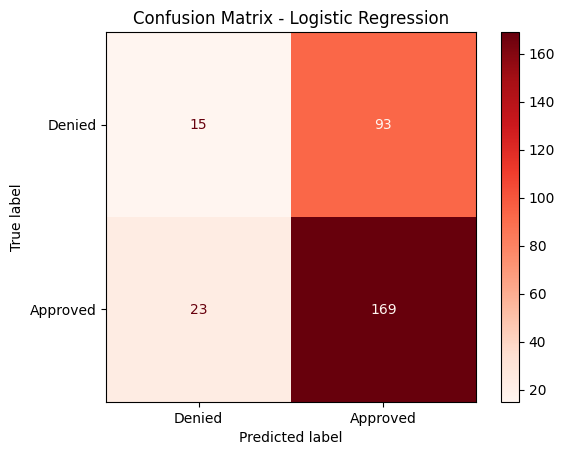

In [22]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

labels = ["Denied", "Approved"]

# Display
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap = "Reds", values_format = "d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [23]:
# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label = 1)
recall = recall_score(y_test, y_pred, pos_label = 1)
f1 = f1_score(y_test, y_pred, pos_label = 1)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

# Generate a classification report
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

Accuracy: 0.61
Precision: 0.65
Recall: 0.88
F1-score: 0.74
Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.14      0.21       108
           1       0.65      0.88      0.74       192

    accuracy                           0.61       300
   macro avg       0.52      0.51      0.47       300
weighted avg       0.55      0.61      0.55       300



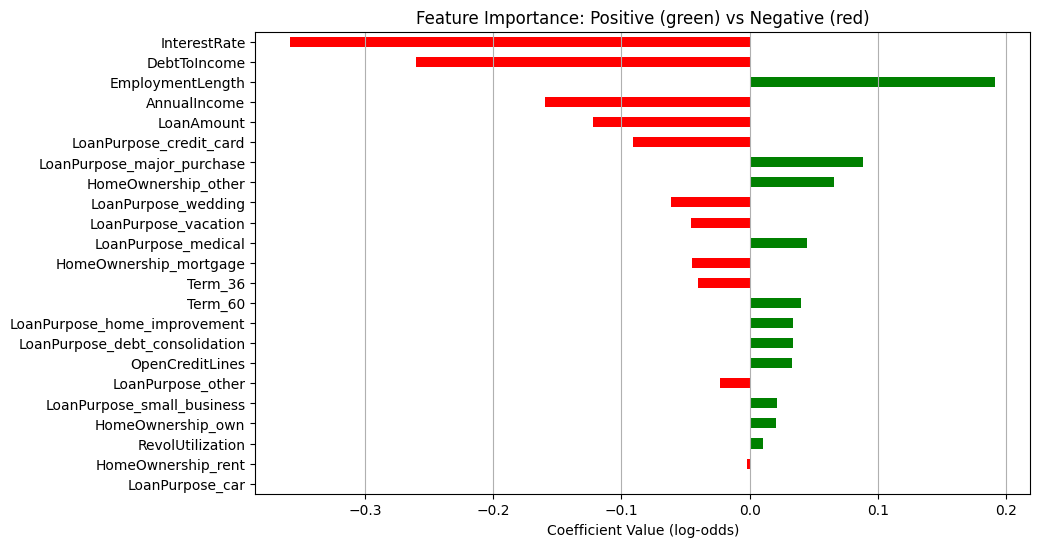

In [24]:
# Get coefficients
coefs = pd.Series(model.coef_[0], index = X_train.columns)

# Sort by absolute value
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending = False).index)

# Create colors: positive = green, negative = red
colors = coefs_sorted.apply(lambda x: "green" if x > 0 else "red")

# Plot horizontal bar chart
coefs_sorted.iloc[::-1].plot(
    kind = "barh",
    color = colors.iloc[::-1],
    figsize = (10, 6)
)

plt.xlabel("Coefficient Value (log-odds)")
plt.title("Feature Importance: Positive (green) vs Negative (red)")
plt.grid(axis = "x")
plt.show()

In [25]:
# Choose a test sample for generating a loan application summary
# 0 is the first row in the DataFrame
sample_index = 0

# Original unscaled row for readable summary
sample_orig = X_test.iloc[sample_index]

In [26]:
# Prepare sample for prediction
sample_scaled = X_test_scaled[sample_index].reshape(1, -1)

# Make prediction
predicted_status = model.predict(sample_scaled)[0]
predicted_proba = model.predict_proba(sample_scaled)[0, 1]

# Create readable summary
print("=== Loan Application Summary ===")
print(f"Annual Income       : ${sample_orig['AnnualIncome']:,.2f}")
print(f"Loan Amount         : ${sample_orig['LoanAmount']:,.2f}")

# Term
for col in sample_orig.index:
    if col.startswith("Term_") and sample_orig[col] == 1:
        term_value = col.replace("Term_", "")
        print(f"Term (months)       : {term_value}")
        break

print(f"Interest Rate       : {sample_orig['InterestRate']:.2f}%")
print(f"Employment Length   : {sample_orig['EmploymentLength']} years")
print(f"Debt-to-Income (DTI): {sample_orig['DebtToIncome']:.2f}")
print(f"Open Credit Lines   : {sample_orig['OpenCreditLines']}")
print(f"Revolving Util      : {sample_orig['RevolUtilization']:.2f}%\n")

# Nicely format categorical features
home_mapping = {col: col.replace("HomeOwnership_", "") for col in sample_orig.index if col.startswith("HomeOwnership_")}
loan_purpose_mapping = {col: col.replace("LoanPurpose_", "") for col in sample_orig.index if col.startswith("LoanPurpose_")}

home_value = [home_mapping[col] for col in home_mapping if sample_orig[col] == 1]
loan_purpose_value = [loan_purpose_mapping[col] for col in loan_purpose_mapping if sample_orig[col] == 1]

print(f"Home Ownership      : {', '.join(home_value)}")
print(f"Loan Purpose        : {', '.join(loan_purpose_value)}\n")

# Show prediction
status_label = "Approved" if predicted_status == 1 else "Not Approved"
print(f"Predicted Loan Status: {status_label}")
print(f"Probability of Approval: {predicted_proba:.2f}")

=== Loan Application Summary ===
Annual Income       : $126,357.00
Loan Amount         : $31,280.66
Term (months)       : 60
Interest Rate       : 8.29%
Employment Length   : 20 years
Debt-to-Income (DTI): 3.82
Open Credit Lines   : 9
Revolving Util      : 95.59%

Home Ownership      : own
Loan Purpose        : other

Predicted Loan Status: Approved
Probability of Approval: 0.79


In [27]:
# We are computing mean absolute SHAP values across the entire dataset to rank overall feature importance.

# Explain model predictions using SHAP
shap_explainer = shap.Explainer(model, X_train_scaled)
shap_values = shap_explainer(X_test_scaled)

# Convert SHAP values to a NumPy array for easier processing
shap_vals_array = shap_values.values

# Compute mean absolute SHAP values for each feature
mean_abs_shap = np.abs(shap_vals_array).mean(axis = 0)

# Create a DataFrame to store feature names and mean absolute SHAP values
shap_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Mean SHAP Value": mean_abs_shap
})

# Sort by mean absolute SHAP value descending
shap_df = shap_df.sort_values(by = "Mean SHAP Value", ascending = False)

# Display the top N features
N = 10
top_features = shap_df.head(N)
print(top_features.to_string(index = False))

                   Feature  Mean SHAP Value
              InterestRate         0.310889
              DebtToIncome         0.215037
          EmploymentLength         0.162643
              AnnualIncome         0.135470
                LoanAmount         0.093052
LoanPurpose_major_purchase         0.052643
   LoanPurpose_credit_card         0.043681
    HomeOwnership_mortgage         0.043281
                   Term_60         0.040350
                   Term_36         0.040350


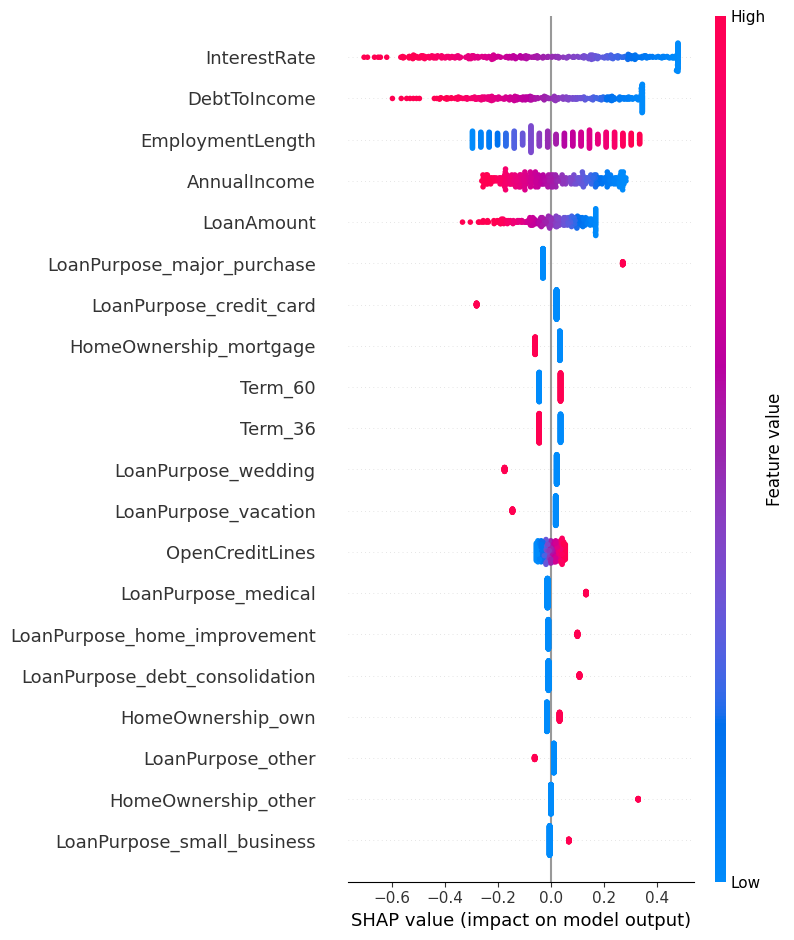

In [28]:
# Cast SHAP values to float32 for plotting
shap_vals_float32 = shap_vals_array.astype("float32")

# Summary plot
shap.summary_plot(shap_vals_float32, X_test, feature_names = X_train.columns)

In [30]:
# Force plot shows how each feature contributes to the prediction for a single sample

# Convert to NumPy arrays
shap_vals_sample = shap_values.values[sample_index]
feature_values = X_test.iloc[sample_index]

# Create the force plot
shap.initjs()

shap.force_plot(
    base_value = shap_explainer.expected_value,
    shap_values = shap_vals_sample,
    features = feature_values,
    feature_names = X_test.columns
)

In [31]:
# These are the columns used during model training
feature_names = X_train.columns.tolist()

# Create a LIME explainer with feature names
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = feature_names,
    class_names = ["Rejected", "Approved"],
    mode = "classification"
)

# Choose a specific prediction instance to explain
prediction_index = 0
prediction_instance = X_test_scaled[prediction_index]

# Explain the prediction
explanation = lime_explainer.explain_instance(
    data_row = prediction_instance,
    predict_fn = model.predict_proba,
    num_features = 10
)

In [32]:
# Visualize the explanation
explanation.show_in_notebook(show_table = True, show_all = False)

<div class="alert alert-block alert-warning">
    <b class="fa fa-solid fa-exclamation-circle"></b>
    <div>
        <p><b>Action Required</b></p>
        <p>Select the database from the drop-down menu at the top of this notebook. It updates the <b>connection_url</b> which is used by SQLAlchemy to make connections to the selected database.</p>
    </div>
</div>

In [34]:
from sqlalchemy import *

db_connection = create_engine(connection_url)

In [35]:
tables = ["train_data", "test_data"]

with db_connection.begin() as conn:
    for table in tables:
        conn.execute(text(f"DROP TABLE IF EXISTS {table};"))

In [36]:
(X_train.join(y_train)).to_sql(
    "train_data",
    con = db_connection,
    if_exists = "replace",
    index = False,
    chunksize = 1000
)

700

In [37]:
(X_test.join(y_test)).to_sql(
    "test_data",
    con = db_connection,
    if_exists = "replace",
    index = False,
    chunksize = 1000
)

300